price: (4, 96)
cons:  (4, 96)
sun:   (4, 96)
pv:    (4,)
OK, optimizer loaded in memory!
PV: [5. 0. 0. 0.]
Battery: [0. 0. 0. 0.]


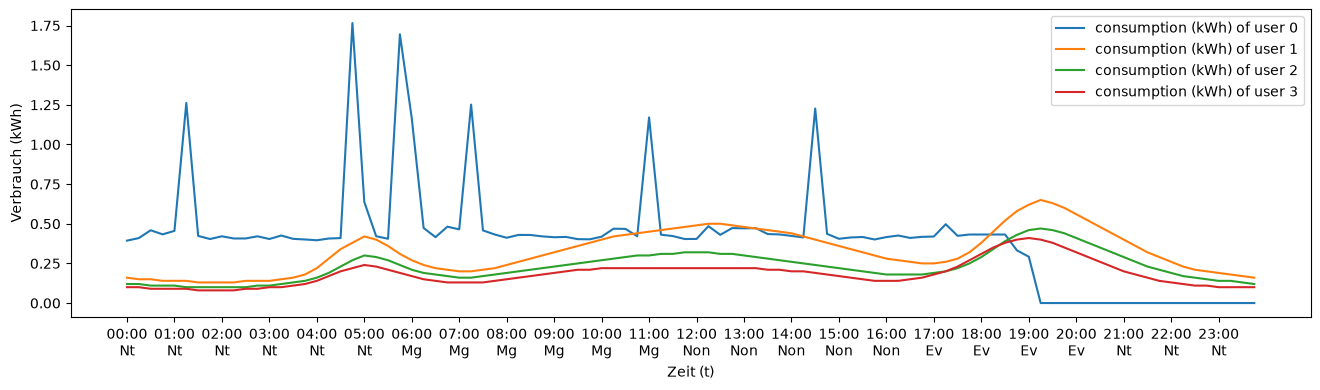

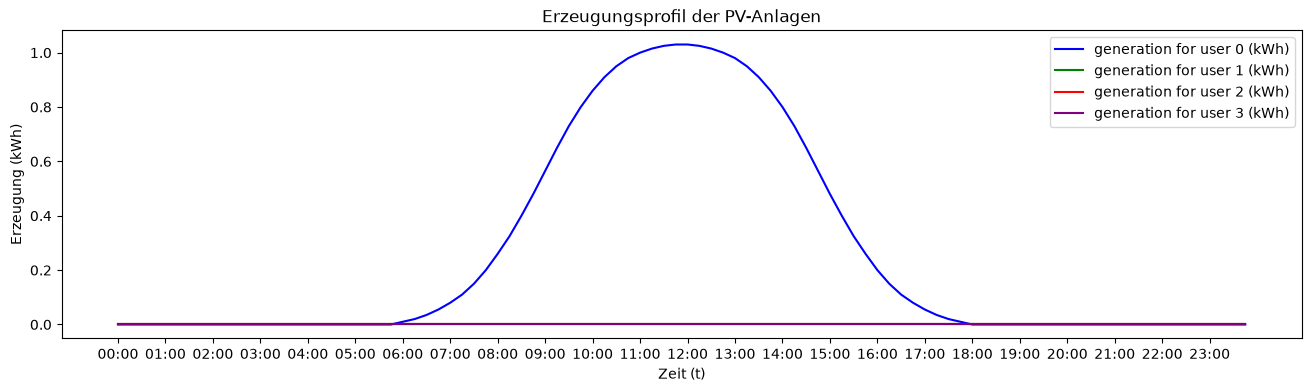

Zeitpunkt t=40
PV-Erzeugung: 0.860 kWh
Consumer 1: Zuteilung=0.430, Sharing=0.400, Verbrauch=0.400, Netzbezug=0.000 kWh
Consumer 2: Zuteilung=0.258, Sharing=0.258, Verbrauch=0.270, Netzbezug=0.012 kWh
Consumer 3: Zuteilung=0.172, Sharing=0.172, Verbrauch=0.220, Netzbezug=0.048 kWh
Cost:  0
t=38: Consumer 1 -> 0.005 kWh Community-Überschuss (zugeteilt: 0.365 kWh, verbraucht: 0.360 kWh)
t=39: Consumer 1 -> 0.020 kWh Community-Überschuss (zugeteilt: 0.400 kWh, verbraucht: 0.380 kWh)
t=40: Consumer 1 -> 0.030 kWh Community-Überschuss (zugeteilt: 0.430 kWh, verbraucht: 0.400 kWh)
t=41: Consumer 1 -> 0.035 kWh Community-Überschuss (zugeteilt: 0.455 kWh, verbraucht: 0.420 kWh)
t=42: Consumer 1 -> 0.045 kWh Community-Überschuss (zugeteilt: 0.475 kWh, verbraucht: 0.430 kWh)
t=43: Consumer 1 -> 0.050 kWh Community-Überschuss (zugeteilt: 0.490 kWh, verbraucht: 0.440 kWh)
t=44: Consumer 1 -> 0.050 kWh Community-Überschuss (zugeteilt: 0.500 kWh, verbraucht: 0.450 kWh)
t=45: Consumer 1 -> 0.048 kWh 

np.float64(0.4300000000000003)

In [3]:
# matplotlib wird zum Plotten importiert
from matplotlib import pyplot as plt

# der Inhalt von optimizer.py wird geladen. Dort befindet sich insbesondere die Klasse Optimizer, die wir gleich verwenden werden.
from optimizer import *

plt.rcParams["figure.figsize"] = (16,4)

# Hier wird ein neues Optimizer-Objekt erstellt und in der Variable opt gespeichert, das die Daten aus dem Ordner "data_test" lädt. 
opt = Optimizer.from_folder2("data_test")

print("price:", opt.price.shape)
print("cons: ", opt.cons.shape)
print("sun:  ", opt.sun.shape)
print("pv:   ", opt.pv.shape)

print("OK, optimizer loaded in memory!")

print("PV:", opt.pv)
print("Battery:", opt.battery)

#plot the consumption of all users
plt.plot(opt.cons[0], label='consumption (kWh) of user 0')
plt.plot(opt.cons[1], label='consumption (kWh) of user 1')
plt.plot(opt.cons[2], label='consumption (kWh) of user 2')
plt.plot(opt.cons[3], label='consumption (kWh) of user 3')

plt.xlabel('Zeit (t)')
plt.ylabel('Verbrauch (kWh)')

# 4 Zeitschritte x 15 min = 60 min = 1 h, daher werden die xticks alle 4 Zeitschritte gesetzt
ticks = list(range(0, len(opt.cons[0]), 4))

# Define labels based on time of day
labels = []
for t in ticks:
    hour = (t // 4) % 24  # Assuming each time step represents 15 minutes
    if 6 <= hour < 12:
        labels.append(f"{hour:02d}:00\nMg")
    elif 12 <= hour < 17:
        labels.append(f"{hour:02d}:00\nNon")
    elif 17 <= hour < 21:
        labels.append(f"{hour:02d}:00\nEv")
    else:
        labels.append(f"{hour:02d}:00\nNt")

plt.xticks(ticks, labels)

plt.legend()
plt.show()

#plot the solar generation profile of each user
#plt.plot(opt.sun[0], label='solar profile (kWh/kWp)', color='yellow')

for user, coluser in zip([0,1,2,3],['blue','green','red','purple']):
    # für jeden Wert s aus dem Solarprofil wird die PV-Leistung des jeweiligen Users multipliziert, um die tatsächliche Erzeugung zu erhalten
    # für User 0 beispielsweise: opt.pv[0] = 5
    # also
    # 5 × sun[0][0]
    # 5 × sun[0][1]
    # 5 × sun[0][2]
    # Dadurch entsteht eine Liste von Werten, die die tatsächliche Erzeugung des Users 0 zu jedem Zeitpunkt darstellen.
    plt.plot([opt.pv[user]*s for s in opt.sun[0]],
             label=f'generation for user {user} (kWh)',
             color=coluser)

plt.xlabel("Zeit (t)")
plt.ylabel("Erzeugung (kWh)")
plt.title("Erzeugungsprofil der PV-Anlagen")

ticks = list(range(0, len(opt.sun[0]), 4))
labels = []

for t in ticks:
    hour = (t // 4) % 24
    labels.append(f"{hour:02d}:00")

plt.xticks(ticks, labels)
plt.legend()
plt.show()

allocation_keys = {
    1: 0.5,
    2: 0.3,
    3: 0.2
}

prosumer = 0

solver = opt.static_sharing_solver(
    allocation_keys=allocation_keys,
    prosumer=prosumer,
    p_p2p=0.12,
    p_feed_in=0.08,
    residual_price=0.0
)

cost = solver.solve(96)

t = 40   # Beispiel-Zeitpunkt

generation = solver.sunf(prosumer, t) * solver.pv[prosumer]

print(f"Zeitpunkt t={t}")
print(f"PV-Erzeugung: {generation:.3f} kWh")

for c, alpha in allocation_keys.items():

    allocation = alpha * generation
    demand = solver.consf(c, t)
    shared = solver.model.imported[c, t].value
    grid = solver.model.el_in[c, t].value

    print(
        f"Consumer {c}: "
        f"Zuteilung={allocation:.3f}, "
        f"Sharing={shared:.3f}, "
        f"Verbrauch={demand:.3f}, "
        f"Netzbezug={grid:.3f} kWh"
    )

print("Cost: ", cost)
solver.print_community_surplus()